In [ ]:
# navigate to the directory of your project in your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Checking Varaince Scheduler

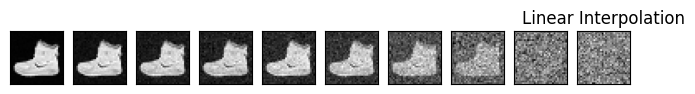

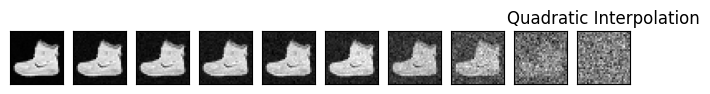

In [35]:
import torch

import matplotlib.pyplot as plt

from main import load_data
from models import VarianceScheduler


# define the configurations of the Variance Scheduler
beta1 = 0.0001
beta2 = 0.02
num_steps = 1000
interpolation = 'linear'

# sample data
dataset = load_data()
sample_image = dataset[0][0].unsqueeze(0)

time_steps = torch.tensor([0, 10, 20, 30, 40, 50, 100, 200, 500, 999], dtype=torch.long)
sample_image = sample_image.repeat(10, 1, 1, 1)

# define the variance scheduler with linear interpolation
var_scheduler = VarianceScheduler(beta_start=beta1, beta_end=beta2, num_steps=num_steps, interpolation=interpolation)

noisy_samples, _ = var_scheduler.add_noise(sample_image, time_steps)

fig, ax = plt.subplots(1, 10)
fig.set_size_inches(8, 2)
for i in range(10):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].imshow(noisy_samples[i, 0].numpy(), cmap='gray')

plt.title('Linear Interpolation')
plt.show()


# define the variance scheduler with quadratic interpolation
interpolation = 'quadratic'
var_scheduler = VarianceScheduler(beta_start=beta1, beta_end=beta2, num_steps=num_steps, interpolation=interpolation)

noisy_samples, _ = var_scheduler.add_noise(sample_image, time_steps)

fig, ax = plt.subplots(1, 10)
fig.set_size_inches(8, 2)
for i in range(10):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].imshow(noisy_samples[i, 0].numpy(), cmap='gray')

plt.title('Quadratic Interpolation')
plt.show()

## Training DDPM

In [36]:
!python main.py --model ddpm --mode train

[!] WARNING, training on CPU could take long!


	 Training DDPM ...
^C
Traceback (most recent call last):
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/main.py", line 88, in <module>
    trainer(model, train_loader, 
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/trainers.py", line 40, in train_ddpm_ddim
    loss = diffusion_model(x, label)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/models.py"

## DDPM Image Generation

saves the results in your project directory as "DDPM_generated_samples.png"

In [80]:
!python main.py --model ddpm --mode generate

Python(63482) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[!] WARNING, training on CPU could take long!
Traceback (most recent call last):
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/main.py", line 96, in <module>
    model.load_state_dict(torch.load(f'checkpoints/{model_type.upper()}.pt'))
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/serialization.py", line 1360, in load
    return _load(
           ^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/serialization.py", line 1848, in _load
    result = unpickler.load()
             ^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/serialization.py", line 1812, in persistent_load
    typed_storage = load_tensor(
                    ^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages

## Trainin DDIM

In [78]:
!python main.py --model ddim --mode train

Python(41519) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[!] WARNING, training on CPU could take long!


	 Training DDIM ...
Traceback (most recent call last):
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/main.py", line 88, in <module>
    trainer(model, train_loader, 
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/trainers.py", line 40, in train_ddpm_ddim
    loss = diffusion_model(x, label)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1747, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/models.py", l

## DDIM Image Generation

saves the results in your project directory as "DDIM_generated_samples.png"

In [81]:
!python main.py --model ddim --mode generate

Python(63491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[!] WARNING, training on CPU could take long!
Traceback (most recent call last):
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/main.py", line 64, in <module>
    model = prepare_ddim()
            ^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/assignment.py", line 70, in prepare_ddim
    network = UNet(in_channels=in_channels, 
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/Assignment 5/models.py", line 115, in __init__
    nn.GroupNorm(num_groups=32, num_channels=channels),
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kabirvanshsinghchadha/Desktop/cmput 328/.venv/lib/python3.12/site-packages/torch/nn/modules/normalization.py", line 292, in __init__
    raise ValueError("num_channels must be divisible by num_groups")
ValueError: num_channels must be divisible by num_groups


## Training VAE

In [76]:
!python main.py --model vae --mode train

Python(28739) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[!] WARNING, training on CPU could take long!
Calculated mid-size: [32, 8, 8]


	 Training VAE ...
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after reshape: torch.Size([128, 32, 8, 8])
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after reshape: torch.Size([128, 32, 8, 8])
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after reshape: torch.Size([128, 32, 8, 8])
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after reshape: torch.Size([128, 32, 8, 8])
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after reshape: torch.Size([128, 32, 8, 8])
Encoder output shape: torch.Size([128, 32, 8, 8])
Flattened shape: torch.Size([128, 2048])
Class embedding shape after re

## VAE Image Generation

saves the results in your project directory as "VAE_generated_samples.png"

In [ ]:
!python main.py --model vae --mode generate

## Training LDDPM

In [ ]:
!python main.py --model lddpm --mode train

## LDDPM Image Generation

saves the results in your project directory as "LDDM_generated_samples.png"

In [ ]:
!python main.py --model lddpm --mode generate